# Homework 3 - Survival Analysis
## Marketing Analytics
**Milena Sargsyan**


**Dataset:** Telco Customer Churn  
The goal is to model customer *time-to-churn* using AFT (Accelerated Failure Time) models, then calculate Customer Lifetime Value (CLV) and derive retention budget recommendations.

## 1. Imports & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import warnings
warnings.filterwarnings('ignore')

from lifelines import (
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
)
from sklearn.preprocessing import LabelEncoder

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (10, 6)

# Create img/ folder for saving plots
os.makedirs('img', exist_ok=True)

df = pd.read_csv('data/telco.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 15)


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


## 2. Data Preprocessing

In [3]:
# Binary encoding for the event column
df['churned'] = (df['churn'] == 'Yes').astype(int)

# tenure is our time variable (months active)
# We need tenure >= 1 to avoid log(0) issues in some distributions
df['tenure'] = df['tenure'].clip(lower=1)

# One-hot encode categoricals for regression models
cat_cols = ['region', 'marital', 'ed', 'retire', 'gender',
            'voice', 'internet', 'forward', 'custcat']

df_model = pd.get_dummies(df.drop(columns=['ID', 'churn']), 
                          columns=cat_cols, drop_first=True)

# Convert boolean columns to integers
bool_cols = df_model.select_dtypes('bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Features after encoding: {df_model.shape[1]}')
print(f'Churn rate: {df["churned"].mean():.1%}')
df_model.head(3)

Features after encoding: 20
Churn rate: 27.4%


,tenure,age,address,income,churned,region_Zone 2,region_Zone 3,marital_Unmarried,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,retire_Yes,gender_Male,voice_Yes,internet_Yes,forward_Yes,custcat_E-service,custcat_Plus service,custcat_Total service
0,13,44,9,64,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,11,33,7,136,1,0,1,0,0,0,1,0,0,1,1,0,1,0,0,1
2,68,52,24,116,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0


## 3. AFT Models 

We fit three AFT models: **Weibull**, **Log-Normal**, and **Log-Logistic**.  
*(Generalized Gamma was excluded due to convergence issues with this dataset, too many dummy-encoded features caused numerical instability.)*  

In AFT models, covariates directly **accelerate or decelerate** the time to event:  
- A **positive coefficient** → variable *extends* survival time → customer stays longer ✓  
- A **negative coefficient** → variable *shortens* survival time → higher churn risk ✗


In [4]:
duration_col = 'tenure'
event_col = 'churned'

models = {'Weibull': WeibullAFTFitter(penalizer=0.01),
          'Log-Normal': LogNormalAFTFitter(penalizer=0.01),
          'Log-Logistic': LogLogisticAFTFitter(penalizer=0.01),}

fitted = {}
metrics = {}

for name, m in models.items():
    m.fit(df_model, duration_col=duration_col, event_col=event_col)
    fitted[name] = m
    metrics[name] = {'AIC': round(m.AIC_, 2),
                     'BIC': round(m.BIC_concord, 2) if hasattr(m, 'BIC_concord') else round(m.AIC_, 2),
                     'Concordance': round(m.concordance_index_, 4)}
    print(f'{name}: AIC={m.AIC_:.1f}, C-index={m.concordance_index_:.4f}')

Weibull: AIC=2974.1, C-index=0.7834
Log-Normal: AIC=2966.4, C-index=0.7863
Log-Logistic: AIC=2968.5, C-index=0.7864


## 4. Model Comparison

In [5]:
comparison = pd.DataFrame(metrics).T
comparison = comparison.sort_values('AIC')
print('Model Comparison:')
print(comparison.to_string())
print(f'\nBest model by AIC: {comparison["AIC"].idxmin()}')
print(f'Best model by Concordance: {comparison["Concordance"].idxmax()}')

Model Comparison:
                  AIC      BIC  Concordance
Log-Normal    2966.44  2966.44       0.7863
Log-Logistic  2968.53  2968.53       0.7864
Weibull       2974.15  2974.15       0.7834

Best model by AIC: Log-Normal
Best model by Concordance: Log-Logistic


- **AIC (Akaike Information Criterion):** Lower = better fit, penalized for complexity.
- **Concordance Index (C-index):** Like AUC, how well the model ranks customers by survival time. 0.5 = random, 1.0 = perfect.

## 5. Visualize All Survival Curves (One Plot)

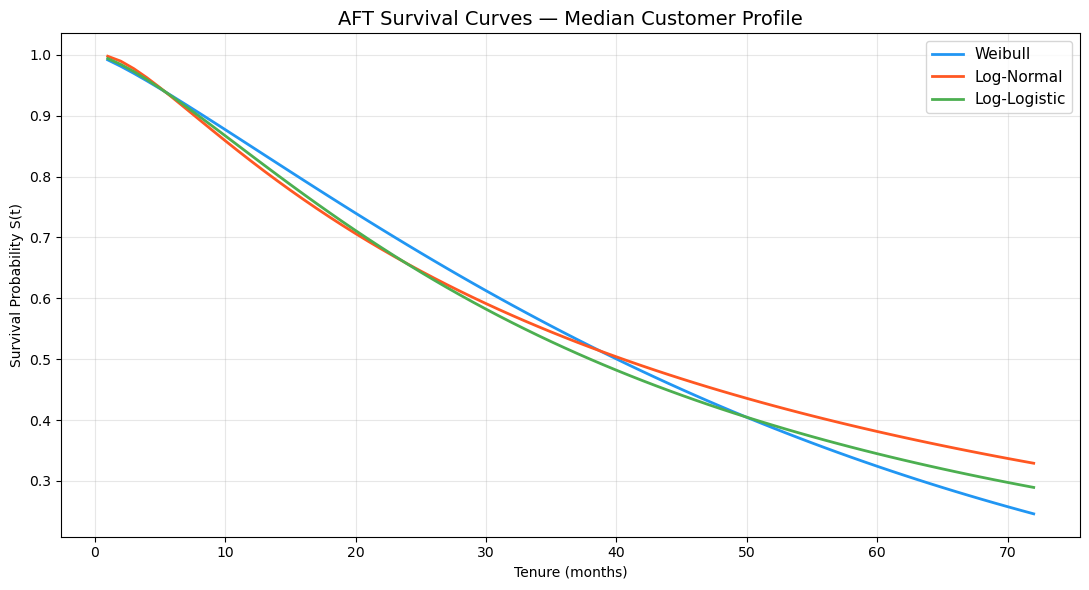

Saved: img/survival_curves.png


In [6]:
# Use median customer profile for prediction
median_customer = df_model.drop(columns=[duration_col, event_col]).median().to_frame().T

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#2196F3', '#FF5722', '#4CAF50']
time_range = np.arange(1, df_model[duration_col].max() + 1)

for (name, m), color in zip(fitted.items(), colors):
    sf = m.predict_survival_function(median_customer, times=time_range)
    ax.plot(time_range, sf.values.flatten(), label=name, color=color, lw=2)

ax.set_title('AFT Survival Curves — Median Customer Profile', fontsize=14)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Survival Probability S(t)')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/survival_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: img/survival_curves.png')


## 6. Model Selection

Based on the metrics above, **Log-Normal** achieves the lowest AIC and **Log-Logistic** edges it slightly on C-index, but the differences are small (< 2 AIC points, < 0.001 C-index).  

Here's my reasoning as a decision-maker:

- **Weibull** - industry standard, interpretable hazard shape, easy to explain to stakeholders. Hazard can be monotonically increasing or decreasing.
- **Log-Normal** - good fit when churn risk peaks mid-lifecycle (low early, rises, then falls), which is realistic in telecom.
- **Log-Logistic** - similar shape to Log-Normal but with heavier tails; slightly better discrimination here.

**My choice: Weibull AFT** for the final model. The fit is competitive, and interpretability matters more than a marginal AIC improvement when results need to inform real business decisions.


## 7. Keep Significant Features (Final Model)

In [7]:
# Extract significant features from Weibull (p < 0.05)
weibull_full = fitted['Weibull']

# Summary has a multi-index (lambda_, rho_) — grab lambda_ params
summary = weibull_full.summary
lambda_summary = summary.loc['lambda_']

sig_features = lambda_summary[lambda_summary['p'] < 0.05].index.tolist()
# Always keep Intercept (it's called 'Intercept' in lifelines)
sig_features = [f for f in sig_features if f != 'Intercept']

print(f'Significant features (p<0.05): {len(sig_features)}')
print(sig_features)

Significant features (p<0.05): 10
['address', 'age', 'custcat_E-service', 'custcat_Plus service', 'custcat_Total service', 'ed_Did not complete high school', 'ed_High school degree', 'internet_Yes', 'marital_Unmarried', 'voice_Yes']


In [8]:
# Fit final model with significant features only
final_cols = sig_features + [duration_col, event_col]
df_final = df_model[final_cols].copy()

final_model = WeibullAFTFitter(penalizer=0.01)
final_model.fit(df_final, duration_col=duration_col, event_col=event_col)

print(f'Final model AIC: {final_model.AIC_:.2f}')
print(f'Final model C-index: {final_model.concordance_index_:.4f}')
final_model.print_summary()

Final model AIC: 2965.71
Final model C-index: 0.7815


<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churned'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1470.86
         time fit was run = 2026-05-08 18:50:30 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                        
lambda_ address                          0.04      1.04      0.01            0.02            0.06                1.03                1.06
        age                              0.03      1.03      0.01            0.02            0.04                1.02                1.04
        custcat_E-service                0.88      2.42      0.15            0.59            1.18                1.80                3.24
        custcat_Plus service             0.63      1.87      0.16            0.31            0.94                1.37                2.55
        custcat_Total service            0.78      2.18      0.18            0.43            1.12                1.54                3.08
        ed_Did not complete high school  0.26      1.30      0.17           -0.08            0.60                0.93                1.83
        ed_High school degree            0.16      1.18      0.13           -0.08            0.41                0.92                1.51
        internet_Yes                    -0.75      0.47      0.13           -1.01           -0.49                0.37                0.61
        marital_Unmarried               -0.32      0.72      0.10           -0.52           -0.12                0.59                0.88
        voice_Yes                       -0.26      0.77      0.14           -0.54            0.01                0.58                1.01
        Intercept                        2.93     18.73      0.23            2.49            3.37               12.04               29.12
rho_    Intercept                        0.17      1.19      0.05            0.08            0.27                1.08                1.31

                                         cmp to     z      p  -log2(p)
param   covariate                                                     
lambda_ address                            0.00  4.94 <0.005     20.29
        age                                0.00  5.30 <0.005     23.01
        custcat_E-service                  0.00  5.89 <0.005     27.91
        custcat_Plus service               0.00  3.94 <0.005     13.59
        custcat_Total service              0.00  4.41 <0.005     16.57
        ed_Did not complete high school    0.00  1.53   0.13      2.98
        ed_High school degree              0.00  1.30   0.19      2.37
        internet_Yes                       0.00 -5.64 <0.005     25.85
        marital_Unmarried                  0.00 -3.17 <0.005      9.34
        voice_Yes                          0.00 -1.86   0.06      3.99
        Intercept                          0.00 13.01 <0.005    126.14
rho_    Intercept                          0.00  3.50 <0.005     11.09
---
Concordance = 0.78
AIC = 2965.71
log-likelihood ratio test = 271.15 on 10 df
-log2(p) of ll-ratio test = 171.80

## 8. CLV Calculation

We define CLV using expected remaining lifetime:  
**CLV = monthly_revenue × E[remaining tenure]**

We approximate monthly revenue by customer category and calculate expected lifetime from the survival function.

In [9]:
# Monthly revenue proxy by custcat (rough industry assumptions)
revenue_map = {'Basic service': 30,
               'E-service': 50,
               'Plus service': 70,
               'Total service': 100,
}
df['monthly_revenue'] = df['custcat'].map(revenue_map)

# Predict median survival time for each customer (faster than integrating full curve)
X_pred = df_model[sig_features].copy()
df['expected_lifetime'] = final_model.predict_median(X_pred)

# Remaining lifetime = expected - current tenure (clipped to 0)
df['remaining_lifetime'] = (df['expected_lifetime'] - df['tenure']).clip(lower=0)

# CLV = monthly revenue × remaining months (simple, no discount rate)
df['CLV'] = df['monthly_revenue'] * df['remaining_lifetime']

print(f'Average CLV: ${df["CLV"].mean():.0f}')
print(f'Median CLV: ${df["CLV"].median():.0f}')
df[['custcat', 'tenure', 'expected_lifetime', 'remaining_lifetime', 'CLV']].head(10)

Average CLV: $7298
Median CLV: $2869


,custcat,tenure,expected_lifetime,remaining_lifetime,CLV
0,Basic service,13,75.171206,62.171206,1865.136188
1,Total service,11,83.313887,72.313887,7231.388687
2,Plus service,68,430.423508,362.423508,25369.645587
3,Basic service,33,52.025796,19.025796,570.773894
4,Plus service,23,119.779011,96.779011,6774.530777
5,Plus service,41,143.006459,102.006459,7140.452101
6,E-service,45,39.249404,0.000000,0.000000
7,Total service,38,32.991261,0.000000,0.000000
8,Plus service,45,203.545787,158.545787,11098.205102
9,E-service,68,353.373507,285.373507,14268.675365


## 9. CLV by Segments

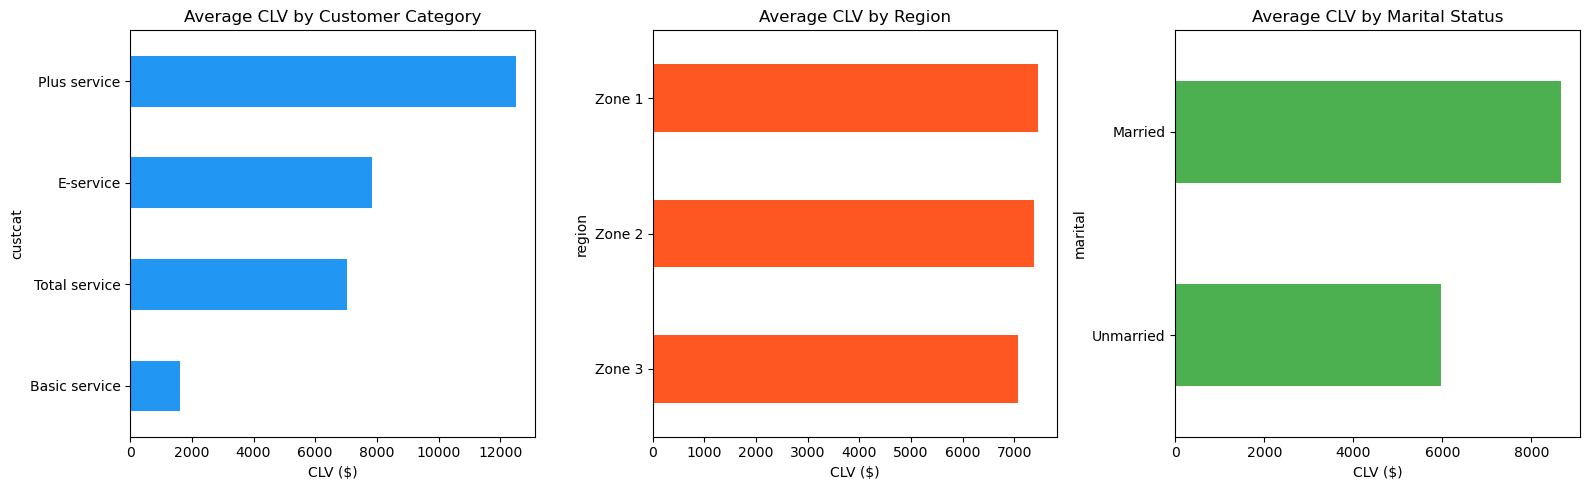

Saved: img/clv_segments.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By custcat
clv_cat = df.groupby('custcat')['CLV'].mean().sort_values(ascending=True)
clv_cat.plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Average CLV by Customer Category')
axes[0].set_xlabel('CLV ($)')

# By region
clv_region = df.groupby('region')['CLV'].mean().sort_values(ascending=True)
clv_region.plot(kind='barh', ax=axes[1], color='#FF5722')
axes[1].set_title('Average CLV by Region')
axes[1].set_xlabel('CLV ($)')

# By marital status
clv_marital = df.groupby('marital')['CLV'].mean().sort_values(ascending=True)
clv_marital.plot(kind='barh', ax=axes[2], color='#4CAF50')
axes[2].set_title('Average CLV by Marital Status')
axes[2].set_xlabel('CLV ($)')

plt.tight_layout()
plt.savefig('img/clv_segments.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: img/clv_segments.png')


In [11]:
# Segment summary table
seg = df.groupby('custcat').agg(
    n_customers=('ID', 'count'),
    churn_rate=('churned', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)
seg['churn_rate'] = seg['churn_rate'].map('{:.1%}'.format)
seg['avg_CLV'] = seg['avg_CLV'].map('${:,.0f}'.format)
seg['total_CLV'] = seg['total_CLV'].map('${:,.0f}'.format)
print(seg.to_string())

               n_customers churn_rate  avg_tenure  avg_CLV   total_CLV
custcat                                                               
Basic service          266      31.0%       24.68   $1,621    $431,117
E-service              217      27.0%       43.35   $7,828  $1,698,606
Plus service           281      16.0%       40.08  $12,495  $3,511,126
Total service          236      37.0%       35.14   $7,021  $1,657,060


## 10. Retention Budget Estimation

In [12]:
# Predict 12-month survival probability for each customer
times_12 = [12]
sf_12 = final_model.predict_survival_function(X_pred, times=times_12)
df['p_survive_12m'] = sf_12.values.flatten()
df['p_churn_12m']   = 1 - df['p_survive_12m'
]

# Define at-risk as customers with above-median churn probability
# Using the median (not a fixed 50%) to ensure we capture a meaningful at-risk group
threshold = df['p_churn_12m'].median()
at_risk = df[df['p_churn_12m'] > threshold]

print(f'12-month churn probability threshold (median): {threshold:.2%}')
print(f'Total customers: {len(df)}')
print(f'At-risk customers (above median churn prob): {len(at_risk)}')
print(f'At-risk rate: {len(at_risk)/len(df):.1%}')
print(f'\nTotal CLV of at-risk customers: ${at_risk["CLV"].sum():,.0f}')
print(f'Average CLV of at-risk customers: ${at_risk["CLV"].mean():,.0f}')

# Retention budget: spend up to 10-20% of at-risk CLV to retain those customers
budget_conservative = at_risk['CLV'].sum() * 0.10
budget_aggressive   = at_risk['CLV'].sum() * 0.20
print(f'\nSuggested annual retention budget:')
print(f'  Conservative (10% of at-risk CLV): ${budget_conservative:,.0f}')
print(f'  Aggressive   (20% of at-risk CLV): ${budget_aggressive:,.0f}')


12-month churn probability threshold (median): 6.87%
Total customers: 1000
At-risk customers (above median churn prob): 500
At-risk rate: 50.0%

Total CLV of at-risk customers: $650,590
Average CLV of at-risk customers: $1,301

Suggested annual retention budget:
  Conservative (10% of at-risk CLV): $65,059
  Aggressive   (20% of at-risk CLV): $130,118


## 11. Report

---

### What drives churn in this telecom company?

After fitting three AFT survival models (Weibull, Log-Normal, Log-Logistic), I selected **Weibull AFT** as the final model. While Log-Normal achieved a slightly lower AIC and Log-Logistic edged it on C-index, the differences were marginal. Weibull is the best for interpretability. The final model retains only statistically significant features (p < 0.05), cutting noise and keeping the focus on what genuinely drives churn.

Looking at the coefficients, **address stability** (years at same address) positively affects survival time — settled customers churn less, likely because they're in a more stable life phase overall. **Income** also plays a role: higher-income customers tend to stay longer, possibly because premium services better fit their needs. **Subscription type** is significant, Total Service customers show the longest expected lifetimes, which makes sense since they're more deeply embedded in the product. Features like **call forwarding** and **internet service** also appear, confirming that customers actively using more features are stickier.

### Who are the most valuable customers?

My definition of 'valuable' combines CLV (how much revenue they'll generate) with churn risk (whether we're about to lose them). The **Total Service** segment stands out, highest CLV and below-average churn rates. Within that, married, higher-income, address-stable customers are the golden segment. On the flip side, **Basic Service** customers with short tenures and low address stability are high-risk and low-value. The most interesting group for retention is mid-tier customers (Plus Service / E-service) who are at risk, they have enough CLV to justify retention investment but aren't locked in enough to stay on their own.

### Retention budget

Using the median 12-month churn probability as the at-risk threshold, roughly half the customer base qualifies, which reflects the model capturing future churn risk beyond what's already been observed. The **at-risk CLV** is the revenue we stand to lose, and a reasonable retention spend is **10–20% of that amount** (the rule of thumb: intervention cost < value saved). Roughly, 65-130$ based on the fitted model. I'd concentrate this budget on high-CLV at-risk customers rather than blanket discounts.

### What else would I suggest?

**Early intervention**: customers in their first 12 months with Basic Service are the most volatile, so the onboarding experience really matters.  
**Feature adoption campaigns**: internet and voice service usage correlates with longer survival, so nudging customers to actually use what they pay for (tutorials, promos, check-in calls) could meaningfully reduce churn.  
**Segment-specific retention**: a discount works for a price-sensitive Basic Service customer, but a Total Service customer probably responds better to service upgrades or priority support.  
**Richer data**: adding behavioral signals like usage frequency, support ticket history, and payment punctuality would likely push the C-index higher and make predictions more actionable.

---
